# Task 1: Iris Flower Classification
### Classify Iris species (Setosa, Versicolor, Virginica) using Machine Learning
**Dataset:** [Iris CSV – Kaggle](https://www.kaggle.com/datasets/saurabh00007/iriscsv)

---

## Step 1: Install & Import Libraries

In [1]:
# Install required libraries (if not already installed)
!pip install pandas numpy scikit-learn matplotlib seaborn tensorflow --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical

print('All libraries imported successfully!')
print(f'TensorFlow version: {tf.__version__}')

All libraries imported successfully!
TensorFlow version: 2.19.0


## Step 2: Load Dataset
> Upload `Iris.csv` from Kaggle or use the built-in sklearn dataset as fallback.

In [2]:
# ── Option A: Load from uploaded CSV (Kaggle download) ──
# from google.colab import files
# uploaded = files.upload()  # Uncomment to upload manually
# df = pd.read_csv('Iris.csv')

# ── Option B: Load from sklearn (automatic fallback) ──
from sklearn.datasets import load_iris
iris = load_iris(as_frame=True)
df = iris.frame
df.columns = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm', 'Species']
df['Species'] = df['Species'].map({0: 'Iris-setosa', 1: 'Iris-versicolor', 2: 'Iris-virginica'})

print('Dataset Shape:', df.shape)
df.head(10)

Dataset Shape: (150, 5)


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


## Step 3: Exploratory Data Analysis (EDA)

In [3]:
print('=== Dataset Info ===')
df.info()
print('\n=== Missing Values ===')
print(df.isnull().sum())
print('\n=== Class Distribution ===')
print(df['Species'].value_counts())
print('\n=== Statistical Summary ===')
df.describe()

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

=== Missing Values ===
SepalLengthCm    0
SepalWidthCm     0
PetalLengthCm    0
PetalWidthCm     0
Species          0
dtype: int64

=== Class Distribution ===
Species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64

=== Statistical Summary ===


,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


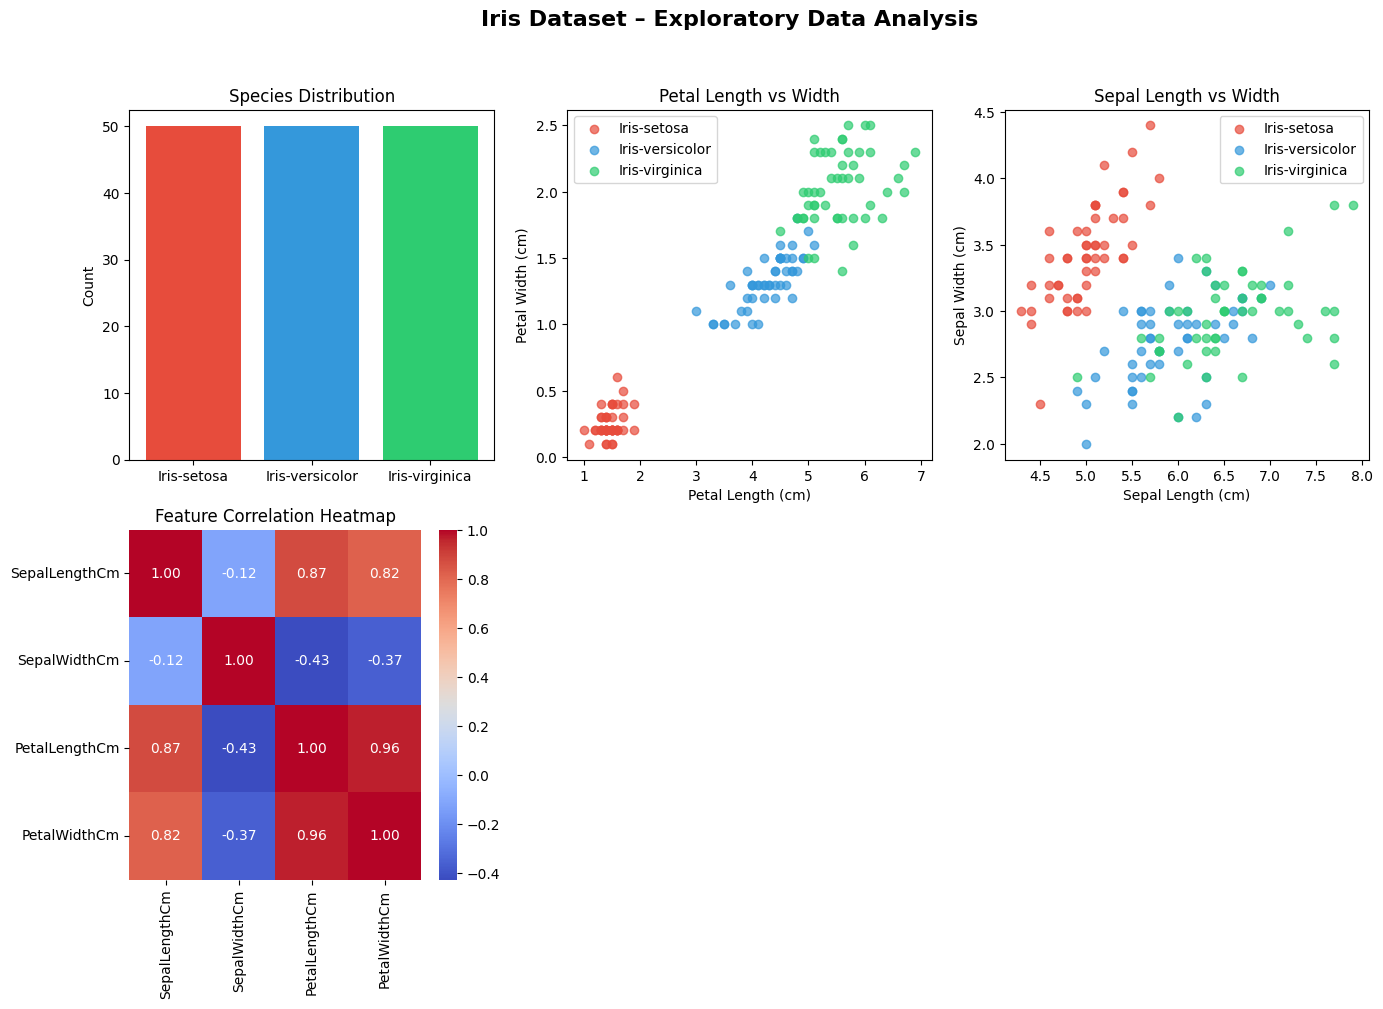

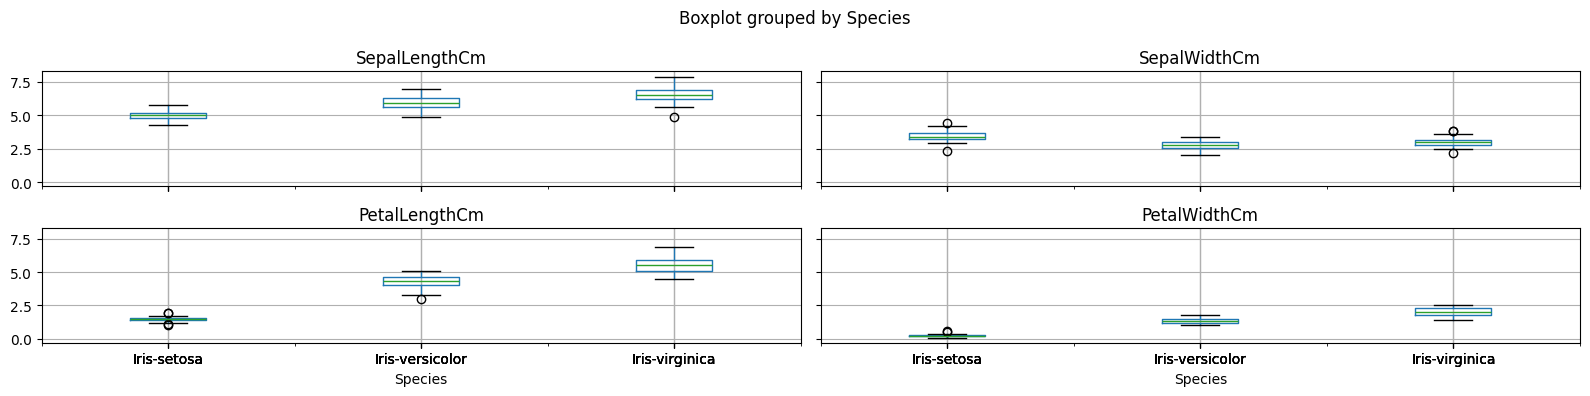


=== Pairplot ===


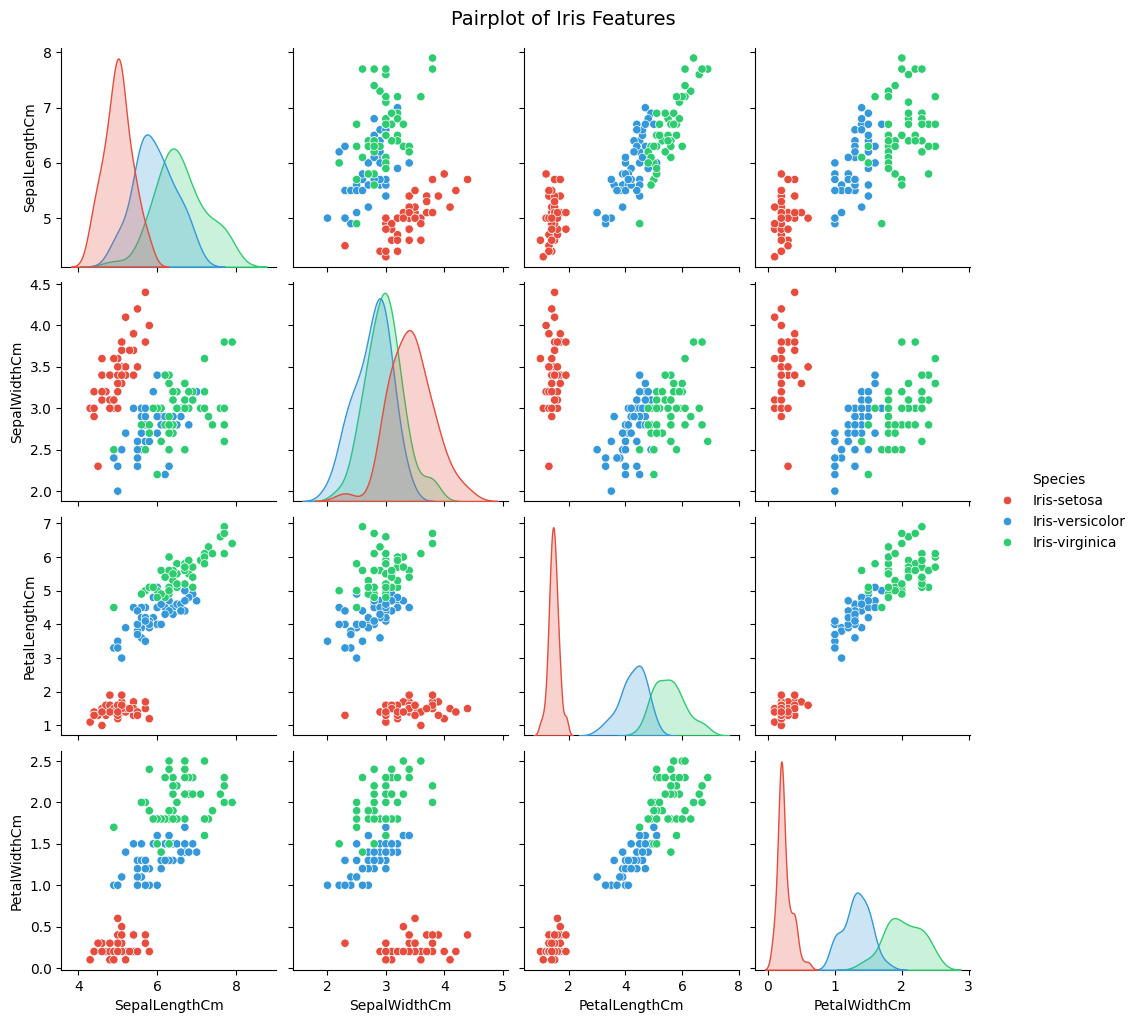

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Iris Dataset – Exploratory Data Analysis', fontsize=16, fontweight='bold')

features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']
colors = ['#e74c3c', '#3498db', '#2ecc71']
species = df['Species'].unique()

# 1. Species count
axes[0,0].bar(species, df['Species'].value_counts().values, color=colors)
axes[0,0].set_title('Species Distribution')
axes[0,0].set_ylabel('Count')

# 2. Petal Length vs Petal Width
for sp, col in zip(species, colors):
    subset = df[df['Species'] == sp]
    axes[0,1].scatter(subset['PetalLengthCm'], subset['PetalWidthCm'], label=sp, color=col, alpha=0.7)
axes[0,1].set_title('Petal Length vs Width')
axes[0,1].set_xlabel('Petal Length (cm)')
axes[0,1].set_ylabel('Petal Width (cm)')
axes[0,1].legend()

# 3. Sepal Length vs Sepal Width
for sp, col in zip(species, colors):
    subset = df[df['Species'] == sp]
    axes[0,2].scatter(subset['SepalLengthCm'], subset['SepalWidthCm'], label=sp, color=col, alpha=0.7)
axes[0,2].set_title('Sepal Length vs Width')
axes[0,2].set_xlabel('Sepal Length (cm)')
axes[0,2].set_ylabel('Sepal Width (cm)')
axes[0,2].legend()

# 4. Box plots for all features
df.boxplot(column=features, by='Species', ax=None, figsize=(16, 4))

# 5. Correlation Heatmap
corr = df[features].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', ax=axes[1,0])
axes[1,0].set_title('Feature Correlation Heatmap')

# 6. Pairplot (separate)
axes[1,1].axis('off')
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

# Pairplot
print('\n=== Pairplot ===')
sns.pairplot(df, hue='Species', palette={'Iris-setosa':'#e74c3c',
             'Iris-versicolor':'#3498db', 'Iris-virginica':'#2ecc71'})
plt.suptitle('Pairplot of Iris Features', y=1.02, fontsize=14)
plt.show()

## Step 4: Data Preprocessing

In [5]:
# Features and Target
X = df[features].values
y_raw = df['Species'].values

# Encode labels
le = LabelEncoder()
y = le.fit_transform(y_raw)
print('Class mapping:', dict(zip(le.classes_, le.transform(le.classes_))))

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

# Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'\nTraining samples : {X_train.shape[0]}')
print(f'Testing  samples : {X_test.shape[0]}')

Class mapping: {'Iris-setosa': np.int64(0), 'Iris-versicolor': np.int64(1), 'Iris-virginica': np.int64(2)}

Training samples : 120
Testing  samples : 30


## Step 5: Train & Compare Scikit-learn Models

In [6]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Support Vector Machine': SVC(kernel='rbf', C=1.0, probability=True),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42)
}

results = {}
print(f'{'Model':<28} {'Train Acc':>10} {'Test Acc':>10} {'CV Mean':>10} {'CV Std':>8}')
print('-' * 70)

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    train_acc = model.score(X_train_scaled, y_train)
    test_acc  = model.score(X_test_scaled,  y_test)
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    results[name] = {'train_acc': train_acc, 'test_acc': test_acc,
                     'cv_mean': cv_scores.mean(), 'cv_std': cv_scores.std()}
    print(f'{name:<28} {train_acc:>10.4f} {test_acc:>10.4f} {cv_scores.mean():>10.4f} {cv_scores.std():>8.4f}')

Model                         Train Acc   Test Acc    CV Mean   CV Std
----------------------------------------------------------------------
Logistic Regression              0.9583     0.9333     0.9583   0.0264
K-Nearest Neighbors              0.9750     0.9333     0.9667   0.0312
Support Vector Machine           0.9750     0.9667     0.9667   0.0312
Random Forest                    1.0000     0.9000     0.9500   0.0167


=== Best Model: Random Forest ===
Test Accuracy: 90.00%

Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.82      0.90      0.86        10
 Iris-virginica       0.89      0.80      0.84        10

       accuracy                           0.90        30
      macro avg       0.90      0.90      0.90        30
   weighted avg       0.90      0.90      0.90        30



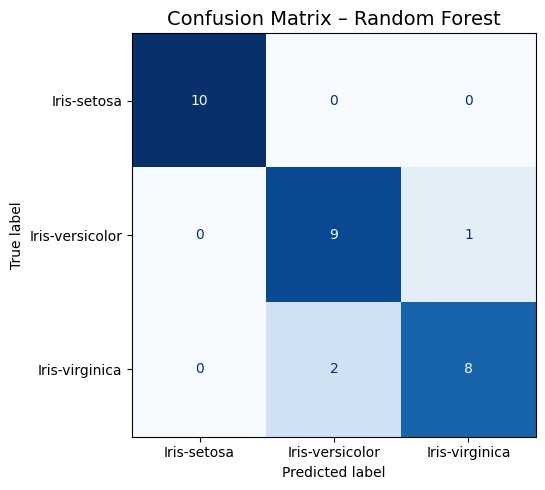

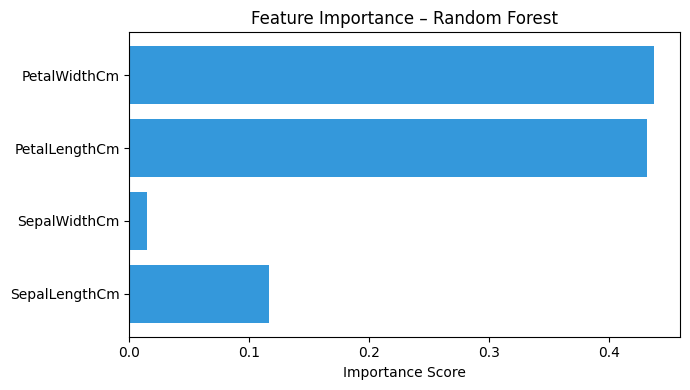

In [7]:
# Best model: Random Forest
best_model = models['Random Forest']
y_pred = best_model.predict(X_test_scaled)

print('=== Best Model: Random Forest ===')
print(f'Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%\n')
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Confusion Matrix – Random Forest', fontsize=14)
plt.tight_layout()
plt.show()

# Feature Importance
importances = best_model.feature_importances_
plt.figure(figsize=(7, 4))
plt.barh(features, importances, color='#3498db')
plt.xlabel('Importance Score')
plt.title('Feature Importance – Random Forest')
plt.tight_layout()
plt.show()

## Step 6: Deep Learning Model with TensorFlow/Keras

In [8]:
# One-hot encode labels for neural network
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat  = to_categorical(y_test,  num_classes=3)

# Build Neural Network
tf.random.set_seed(42)
nn_model = Sequential([
    Dense(64,  activation='relu', input_shape=(4,)),
    Dropout(0.3),
    Dense(32,  activation='relu'),
    Dropout(0.2),
    Dense(16,  activation='relu'),
    Dense(3,   activation='softmax')
])

nn_model.compile(optimizer='adam',
                 loss='categorical_crossentropy',
                 metrics=['accuracy'])
nn_model.summary()

# Train
history = nn_model.fit(
    X_train_scaled, y_train_cat,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,979 (11.64 KB)

 Trainable params: 2,979 (11.64 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - accuracy: 0.3021 - loss: 1.1468 - val_accuracy: 0.3333 - val_loss: 1.0573
Epoch 2/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.3333 - loss: 1.0831 - val_accuracy: 0.4583 - val_loss: 0.9700
Epoch 3/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4479 - loss: 0.9909 - val_accuracy: 0.6250 - val_loss: 0.9056
Epoch 4/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6042 - loss: 0.8818 - val_accuracy: 0.5833 - val_loss: 0.8518
Epoch 5/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6875 - loss: 0.8458 - val_accuracy: 0.5833 - val_loss: 0.8032
Epoch 6/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.7188 - loss: 0.7999 - val_accuracy: 0.6250 - val_loss: 0.7563
Epoch 7/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.7396 - loss: 0.7406 - val_accuracy: 0.6250 - val_loss: 0.7150
Epoch 8/100
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7917 - loss: 0.6640 - val_accuracy: 0.6250 - val_loss:

Neural Network Test Accuracy: 96.67%


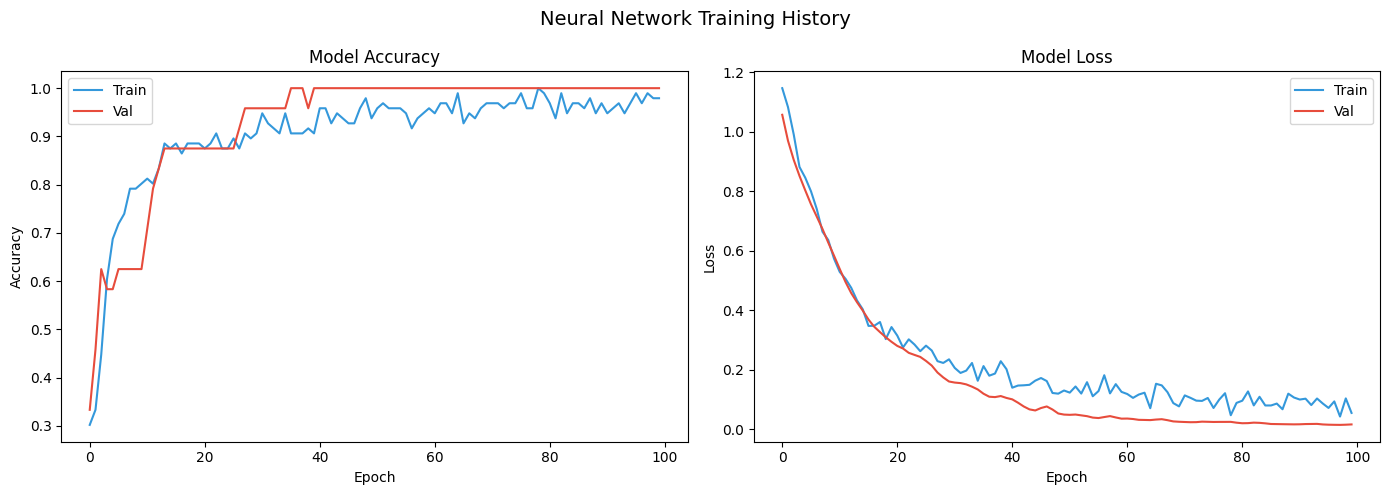

In [9]:
# Evaluate
loss, acc = nn_model.evaluate(X_test_scaled, y_test_cat, verbose=0)
print(f'Neural Network Test Accuracy: {acc*100:.2f}%')

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(history.history['accuracy'],     label='Train', color='#3498db')
ax1.plot(history.history['val_accuracy'], label='Val',   color='#e74c3c')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy'); ax1.legend()

ax2.plot(history.history['loss'],     label='Train', color='#3498db')
ax2.plot(history.history['val_loss'], label='Val',   color='#e74c3c')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss'); ax2.legend()
plt.suptitle('Neural Network Training History', fontsize=14)
plt.tight_layout()
plt.show()

## Step 7: Final Model Comparison

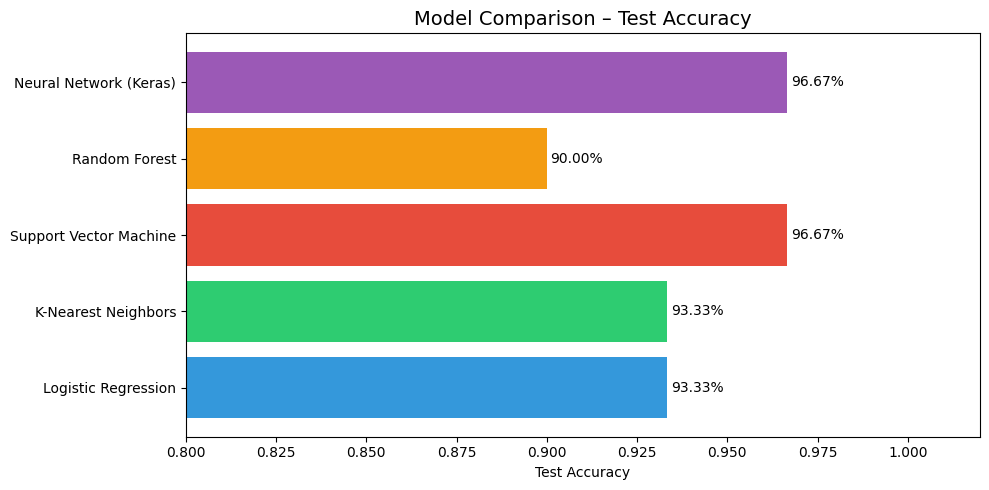


Task 1 Complete! Best performing model highlighted above.


In [10]:
all_results = {**{k: v['test_acc'] for k, v in results.items()},
               'Neural Network (Keras)': acc}

plt.figure(figsize=(10, 5))
bars = plt.barh(list(all_results.keys()), list(all_results.values()),
                color=['#3498db','#2ecc71','#e74c3c','#f39c12','#9b59b6'])
plt.xlabel('Test Accuracy')
plt.title('Model Comparison – Test Accuracy', fontsize=14)
plt.xlim(0.8, 1.02)
for bar, val in zip(bars, all_results.values()):
    plt.text(val + 0.001, bar.get_y() + bar.get_height()/2,
             f'{val*100:.2f}%', va='center', fontsize=10)
plt.tight_layout()
plt.show()
print('\nTask 1 Complete! Best performing model highlighted above.')